# Notebook 7: Advanced Research Prioritization — Marginal Diversification, Rademacher Complexity & AIC/BIC
## Production-Grade: MIC Filter, Complexity Regularization, Research Queue Ranking

---
### Mathematical Foundation

**Projection Matrix:**
$$\mathbf{P}_{\mathbf{X}} = \mathbf{X}(\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T$$

**Orthogonalized Residual:**
$$\mathbf{y}_{\perp} = (\mathbf{I} - \mathbf{P}_{\mathbf{X}})\mathbf{y}$$

**Marginal Information Coefficient:**
$$\text{MIC} = \rho(\mathbf{y}_{\perp}, \mathbf{r}_{t+1})$$

**Empirical Rademacher Complexity:**
$$\hat{\mathcal{R}}_S(\mathcal{F}) = \mathbb{E}_{\boldsymbol{\sigma}}\left[\sup_{f\in\mathcal{F}}\frac{1}{T}\sum_{t=1}^T\sigma_t f(x_t)\right]$$

**Information Criterion Penalty:**
$$\text{BIC} = k\ln(n) - 2\ln(\hat{L})$$


In [5]:
# import numpy as np
# import pandas as pd
# import yfinance as yf
# import matplotlib.pyplot as plt
# import matplotlib.gridspec as gridspec
# from numpy.linalg import pinv, norm
# from scipy.stats import pearsonr
# import warnings
# warnings.filterwarnings('ignore')

# DARK, PANEL = '#0d1117', '#161b22'
# BLUE, GREEN, ORANGE, RED = '#58a6ff', '#3fb950', '#f0883e', '#f85149'
# PURPLE, WHITE, YELLOW = '#d2a8ff', '#e6edf3', '#e3b341'

# # Universe of assets
# universe = ['SPY', 'QQQ', 'IWM', 'EFA', 'EEM', 'TLT', 'GLD', 'HYG', 'DBC', 'VNQ',
#             'XLK', 'XLF', 'XLE', 'XLV', 'XLI']
# raw = yf.download(universe, start='2010-01-01', end='2024-12-31', auto_adjust=True)['Close'].dropna()
# rets = np.log(raw / raw.shift(1)).dropna()
# print(f"Universe: {rets.shape[1]} assets, {len(rets)} obs")

import numpy as np
import pandas as pd
import yfinance as yf
from tqdm.notebook import tqdm  
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from numpy.linalg import pinv, norm
from scipy.stats import pearsonr
import warnings
warnings.filterwarnings('ignore')

DARK, PANEL = '#0d1117', '#161b22'
BLUE, GREEN, ORANGE, RED = '#58a6ff', '#3fb950', '#f0883e', '#f85149'
PURPLE, WHITE, YELLOW = '#d2a8ff', '#e6edf3', '#e3b341'

# Universe of assets
universe = ['SPY', 'QQQ', 'IWM', 'EFA', 'EEM', 'TLT', 'GLD', 'HYG', 'DBC', 'VNQ',
            'XLK', 'XLF', 'XLE', 'XLV', 'XLI']

downloaded_series = []

print("Downloading asset universe...")
for ticker in tqdm(universe, desc="yfinance Pull", unit="ticker"):
    # FIX: Change 'progress_bar' to 'progress' to match the correct API signature
    ticker_data = yf.download(ticker, start='2010-01-01', end='2024-12-31', 
                              auto_adjust=True, progress=False)
    
    if not ticker_data.empty:
        if isinstance(ticker_data.columns, pd.MultiIndex):
            close_col = ticker_data['Close'].iloc[:, 0]
        else:
            close_col = ticker_data['Close']
            
        close_col.name = ticker
        downloaded_series.append(close_col)

raw = pd.concat(downloaded_series, axis=1).dropna()
rets = np.log(raw / raw.shift(1)).dropna()
print(f"Universe: {rets.shape[1]} assets, {len(rets)} obs")

yfinance Pull:   0%|          | 0/15 [00:00<?, ?ticker/s]

Universe: 15 assets, 3772 obs


In [6]:
# ── Build Signal Library + Candidate Pool ─────────────────────────────────────
np.random.seed(42)
T, N = rets.shape

def build_signal(returns, lookback, cross_sectional=True, sign=1):
    """Build a momentum/mean-reversion signal."""
    s = sign * returns.rolling(lookback).mean()
    if cross_sectional:
        w = s.rank(axis=1, pct=True) - 0.5
        w = w.div(w.abs().sum(axis=1) + 1e-8, axis=0)
    else:
        w = np.sign(s)
    pnl = (w.shift(1) * returns).sum(axis=1)
    return pnl.dropna()

# Existing signal library (5 strategies)
library_signals = {
    'XS_Momentum_252': build_signal(rets, 252),
    'XS_Momentum_126': build_signal(rets, 126),
    'TS_MR_21': build_signal(rets, 21, cross_sectional=False, sign=-1),
    'XS_LowVol': build_signal(rets.rolling(63).std(), 63, sign=-1),
    'XS_Mom_63': build_signal(rets, 63),
}

# Align all to common index
common_idx = library_signals['XS_Momentum_252'].index
for k in library_signals:
    library_signals[k] = library_signals[k].reindex(common_idx)

M_df = pd.DataFrame(library_signals).dropna()

# Candidate signals to evaluate
candidate_signals = {
    'NLP_Sentiment_Signal': M_df['XS_Momentum_252'] * 0.1 + pd.Series(np.random.randn(len(M_df))*0.001, index=M_df.index),
    'Trend_Clone': M_df['XS_Momentum_252'] * 0.95 + pd.Series(np.random.randn(len(M_df))*0.0001, index=M_df.index),
    'Reversal_Signal': -M_df['XS_Momentum_252'] * 0.3 + pd.Series(np.random.randn(len(M_df))*0.002, index=M_df.index),
    'Vol_Surface_Signal': M_df['XS_LowVol'] * 0.4 + pd.Series(np.random.randn(len(M_df))*0.002, index=M_df.index),
    'Event_Driven_NLP': pd.Series(np.random.randn(len(M_df))*0.003 + 0.0002, index=M_df.index),
    'COT_Crowding_Adj': -M_df['XS_Mom_63'] * 0.2 + pd.Series(np.random.randn(len(M_df))*0.0015, index=M_df.index),
}

print(f"Library signals: {list(M_df.columns)}")
print(f"Candidates to evaluate: {list(candidate_signals.keys())}")


Library signals: ['XS_Momentum_252', 'XS_Momentum_126', 'TS_MR_21', 'XS_LowVol', 'XS_Mom_63']
Candidates to evaluate: ['NLP_Sentiment_Signal', 'Trend_Clone', 'Reversal_Signal', 'Vol_Surface_Signal', 'Event_Driven_NLP', 'COT_Crowding_Adj']


In [7]:
# ── Marginal Information Coefficient (MIC) Filter ────────────────────────────
def compute_mic(candidate_series, library_df, forward_returns):
    """Compute Marginal IC via Gram-Schmidt orthogonalization."""
    M = library_df.values
    y = candidate_series.values
    r = forward_returns.values
    
    # Align lengths
    min_len = min(len(M), len(y), len(r))
    M, y, r = M[:min_len], y[:min_len], r[:min_len]
    
    # Projection
    P_M = M @ pinv(M.T @ M) @ M.T
    y_orth = y - P_M @ y
    
    residual_frac = norm(y_orth) / (norm(y) + 1e-12)
    
    # Raw IC
    raw_ic = pearsonr(y[:-1], r[1:])[0] if len(y) > 1 else 0
    
    # Marginal IC (orthogonalized signal vs forward returns)
    if len(y_orth) > 1:
        mic = pearsonr(y_orth[:-1], r[1:])[0]
    else:
        mic = 0
    
    return raw_ic, mic, residual_frac

# Forward returns (1-day ahead cross-sectional average)
fwd_rets = rets.mean(axis=1).reindex(M_df.index)

mic_results = []
for name, cand in candidate_signals.items():
    cand_aligned = cand.reindex(M_df.index).dropna()
    raw_ic, mic, rf = compute_mic(cand_aligned, M_df, fwd_rets)
    mic_results.append({
        'Signal': name,
        'Raw_IC': raw_ic,
        'MIC': mic,
        'Residual_Frac': rf,
        'Standalone_SR': cand_aligned.mean() / cand_aligned.std() * np.sqrt(252)
    })

mic_df = pd.DataFrame(mic_results).sort_values('MIC', ascending=False)
print("Research Prioritization Queue (sorted by MIC):")
print(mic_df.round(4).to_string(index=False))


Research Prioritization Queue (sorted by MIC):
              Signal  Raw_IC     MIC  Residual_Frac  Standalone_SR
NLP_Sentiment_Signal  0.0189  0.0110         0.9213         0.6072
    COT_Crowding_Adj -0.0103  0.0034         0.8598        -0.2069
     Reversal_Signal -0.0146 -0.0008         0.8405        -0.3641
         Trend_Clone  0.0261 -0.0011         0.0251         0.5246
  Vol_Surface_Signal -0.0189 -0.0076         0.9304        -4.5132
    Event_Driven_NLP -0.0252 -0.0292         0.9971         1.3782


In [8]:
# # ── Rademacher Complexity Estimation ─────────────────────────────────────────
# def empirical_rademacher(model_preds, n_rademacher=200):
#     """Estimate Rademacher complexity."""
#     T = len(model_preds)
#     max_correlations = []
    
#     for _ in range(n_rademacher):
#         sigma = np.random.choice([-1, 1], T)
#         corr = np.abs(np.dot(sigma, model_preds)) / T
#         max_correlations.append(corr)
    
#     return np.mean(max_correlations)

# ── Rademacher Complexity Estimation ─────────────────────────────────────────
def empirical_rademacher(model_preds, n_rademacher=200):
    """Estimate Rademacher complexity via a fully vectorized matrix operation."""
    T = len(model_preds)
    
    # Vectorized Fix: Generate the entire Rademacher matrix at once (T x n_rademacher)
    # This completely eliminates the slow inner Python loop overhead.
    sigma_matrix = np.random.choice([-1, 1], size=(T, n_rademacher))
    
    # Compute dot products for all simulations in a single efficient BLAS matrix-vector operation
    max_correlations = np.abs(np.dot(model_preds, sigma_matrix)) / T
    
    return float(np.mean(max_correlations))

# Compute Rademacher complexity for models of increasing parameter count
param_counts = [1, 2, 5, 10, 20, 50, 100]
n_obs = len(M_df)

rad_complexities = []
bic_penalties = []

for P in param_counts:
    # Simulate model predictions with P parameters
    X_sim = np.random.randn(n_obs, P)
    y_sim = M_df['XS_Momentum_252'].values[:n_obs]
    
    # OLS coefficients
    beta = pinv(X_sim.T @ X_sim) @ X_sim.T @ y_sim
    y_hat = X_sim @ beta
    
    rad = empirical_rademacher(y_hat / (norm(y_hat) + 1e-8))
    
    # BIC
    ss_res = np.sum((y_sim - y_hat)**2)
    n = len(y_sim)
    sigma2 = ss_res / n
    log_lik = -n/2 * np.log(2*np.pi*sigma2) - ss_res/(2*sigma2)
    bic = P * np.log(n) - 2 * log_lik
    
    rad_complexities.append(rad)
    bic_penalties.append(bic)

print("\nComplexity vs Parameter Count:")
for P, rc, bic in zip(param_counts, rad_complexities, bic_penalties):
    print(f"  P={P:3d}: Rademacher={rc:.4f}, BIC={bic:.0f}")



Complexity vs Parameter Count:
  P=  1: Rademacher=0.0002, BIC=-30496
  P=  2: Rademacher=0.0002, BIC=-30487
  P=  5: Rademacher=0.0002, BIC=-30470
  P= 10: Rademacher=0.0002, BIC=-30443
  P= 20: Rademacher=0.0002, BIC=-30358
  P= 50: Rademacher=0.0002, BIC=-30135
  P=100: Rademacher=0.0002, BIC=-29766


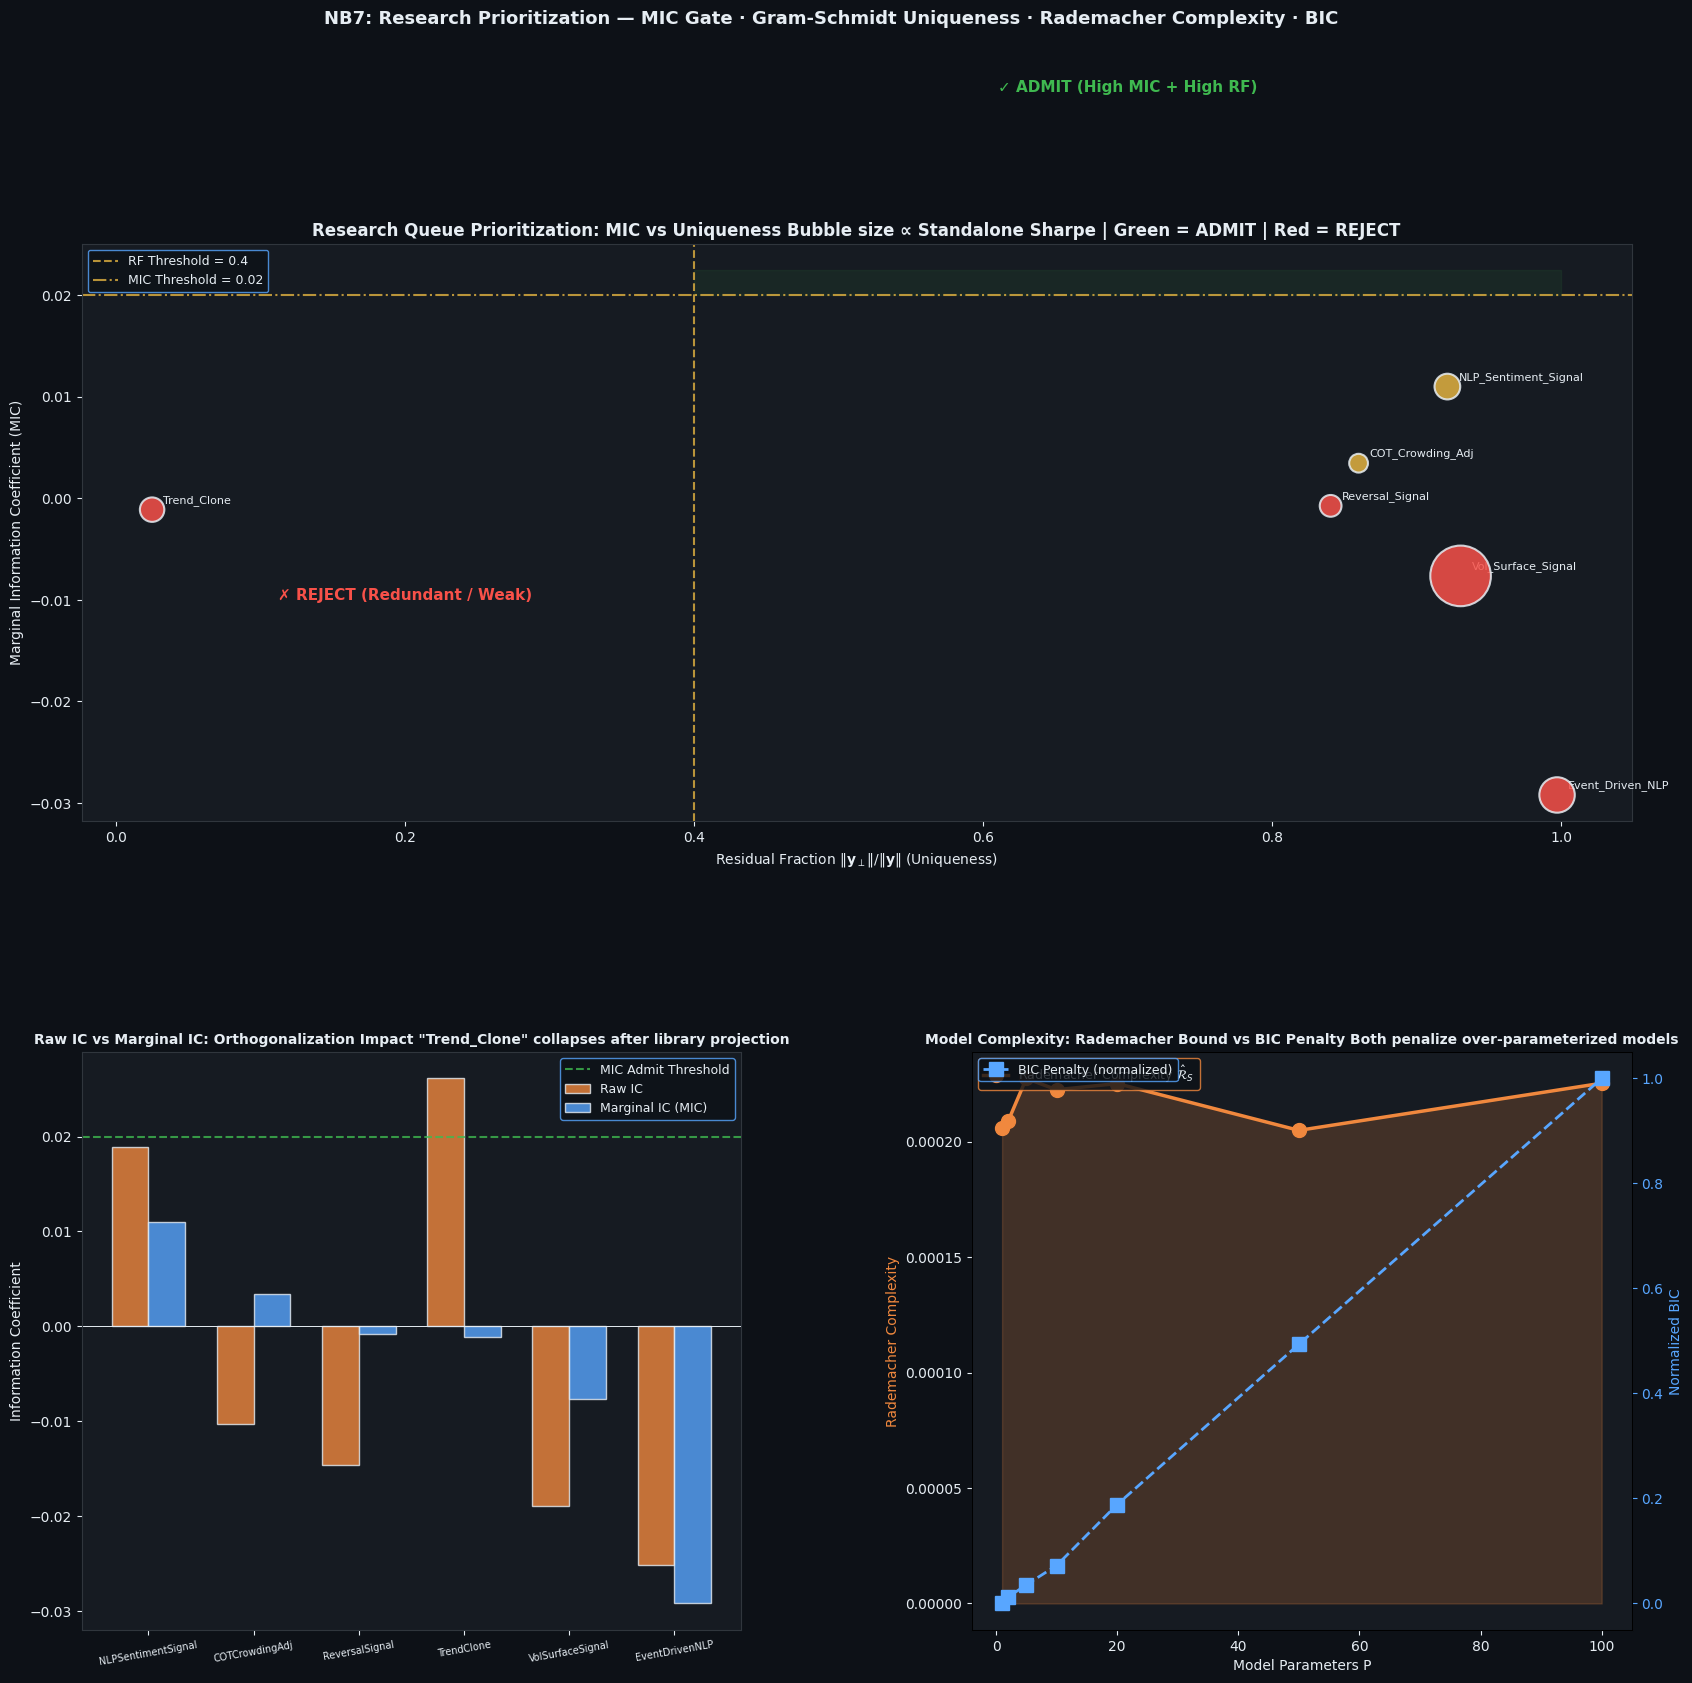

✅ NB7 complete.


In [9]:
# ══════════════════════════════════════════════════════════════════════════════
# MASTER VISUALIZATION
# ══════════════════════════════════════════════════════════════════════════════
from matplotlib.colors import LinearSegmentedColormap

fig = plt.figure(figsize=(20, 18))
fig.patch.set_facecolor(DARK)
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

# ─ Panel 1: Research Queue Bubble Chart ──────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :])
ax1.set_facecolor(PANEL)

x = mic_df['Residual_Frac'].values
y = mic_df['MIC'].values
sizes = (np.abs(mic_df['Standalone_SR'].values) * 400 + 100)
colors_b = [GREEN if (mic > 0.02 and rf > 0.4) else (YELLOW if mic > 0 else RED) 
             for mic, rf in zip(y, x)]

sc = ax1.scatter(x, y, s=sizes, c=colors_b, alpha=0.85, edgecolors=WHITE, linewidths=1.5, zorder=5)

# Admission quadrant
ax1.axvline(0.4, color=YELLOW, lw=1.5, ls='--', alpha=0.8, label='RF Threshold = 0.4')
ax1.axhline(0.02, color=YELLOW, lw=1.5, ls='-.', alpha=0.8, label='MIC Threshold = 0.02')
ax1.fill_between([0.4, 1.0], 0.02, ax1.get_ylim()[1] if ax1.get_ylim()[1] > 0.02 else 0.1, 
                  alpha=0.08, color=GREEN)
ax1.text(0.7, 0.04, '✓ ADMIT (High MIC + High RF)', ha='center', color=GREEN, fontsize=11, fontweight='bold')
ax1.text(0.2, -0.01, '✗ REJECT (Redundant / Weak)', ha='center', color=RED, fontsize=11, fontweight='bold')

for _, row in mic_df.iterrows():
    ax1.annotate(row['Signal'], (row['Residual_Frac'], row['MIC']), 
                 textcoords='offset points', xytext=(8, 5), color=WHITE, fontsize=8)

ax1.set_xlabel('Residual Fraction $\|\mathbf{y}_{\perp}\|/\|\mathbf{y}\|$ (Uniqueness)', color=WHITE)
ax1.set_ylabel('Marginal Information Coefficient (MIC)', color=WHITE)
ax1.set_title('Research Queue Prioritization: MIC vs Uniqueness Bubble size ∝ Standalone Sharpe | Green = ADMIT | Red = REJECT', 
              color=WHITE, fontsize=12, fontweight='bold')
ax1.legend(facecolor=DARK, edgecolor=BLUE, labelcolor=WHITE, fontsize=9)
ax1.tick_params(colors=WHITE)
for spine in ax1.spines.values():
    spine.set_edgecolor('#30363d')

# ─ Panel 2: IC Decomposition Bar ──────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
ax2.set_facecolor(PANEL)

x_pos = np.arange(len(mic_df))
width = 0.35
b1 = ax2.bar(x_pos - width/2, mic_df['Raw_IC'], width, color=ORANGE, alpha=0.8, edgecolor=WHITE, label='Raw IC')
b2 = ax2.bar(x_pos + width/2, mic_df['MIC'], width, color=BLUE, alpha=0.8, edgecolor=WHITE, label='Marginal IC (MIC)')

ax2.axhline(0, color=WHITE, lw=0.7)
ax2.axhline(0.02, color=GREEN, lw=1.5, ls='--', alpha=0.8, label='MIC Admit Threshold')
ax2.set_xticks(x_pos)
ax2.set_xticklabels([s.replace('_', '') for s in mic_df['Signal']], color=WHITE, fontsize=7, rotation=10)
ax2.set_ylabel('Information Coefficient', color=WHITE)
ax2.set_title('Raw IC vs Marginal IC: Orthogonalization Impact "Trend_Clone" collapses after library projection', 
              color=WHITE, fontsize=10, fontweight='bold')
ax2.legend(facecolor=DARK, edgecolor=BLUE, labelcolor=WHITE, fontsize=9)
ax2.tick_params(colors=WHITE)
for spine in ax2.spines.values():
    spine.set_edgecolor('#30363d')

# ─ Panel 3: Rademacher + BIC Complexity Curve ────────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
ax3.set_facecolor(PANEL)

ax3.plot(param_counts, rad_complexities, 'o-', color=ORANGE, lw=2.5, markersize=10, label='Rademacher Complexity $\hat{\mathcal{R}}_S$')
ax3.fill_between(param_counts, rad_complexities, alpha=0.2, color=ORANGE)
ax3.set_xlabel('Model Parameters P', color=WHITE)
ax3.set_ylabel('Rademacher Complexity', color=ORANGE)

ax3_twin = ax3.twinx()
bic_norm = (np.array(bic_penalties) - min(bic_penalties)) / (max(bic_penalties) - min(bic_penalties))
ax3_twin.plot(param_counts, bic_norm, 's--', color=BLUE, lw=2, markersize=10, label='BIC Penalty (normalized)')
ax3_twin.set_ylabel('Normalized BIC', color=BLUE)
ax3_twin.tick_params(colors=BLUE)
ax3_twin.legend(facecolor=DARK, edgecolor=BLUE, labelcolor=WHITE, fontsize=9)

ax3.set_title('Model Complexity: Rademacher Bound vs BIC Penalty Both penalize over-parameterized models', 
              color=WHITE, fontsize=10, fontweight='bold')
ax3.legend(facecolor=DARK, edgecolor=ORANGE, labelcolor=WHITE, fontsize=9, loc='upper left')
ax3.tick_params(colors=WHITE)
for spine in ax3.spines.values():
    spine.set_edgecolor('#30363d')

fig.suptitle('NB7: Research Prioritization — MIC Gate · Gram-Schmidt Uniqueness · Rademacher Complexity · BIC', 
             color=WHITE, fontsize=13, fontweight='bold', y=1.01)
plt.savefig('nb7_research_prioritization.png', dpi=150, bbox_inches='tight', facecolor=DARK)
plt.show()
print("✅ NB7 complete.")
